In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import re
import numpy as np

In [38]:
root_path = Path.cwd().resolve().parents[0]
data_path = root_path / 'data' / 'processed'
inbound = pd.read_csv(data_path / 'inbound_students_processed.csv')
outbound = pd.read_csv(data_path / 'outbound_students_processed.csv')

In [ ]:
# drop unneeded column and years after 2025 as there are few values
# also drop rows with nan country
inbound = inbound[inbound['year'] < 2025].drop(columns=['Unnamed: 0']).dropna(subset = ['country'])
outbound = outbound[outbound['year'] < 2025].drop(columns=['Unnamed: 0']).dropna(subset=['country'])

In [41]:
top_6_inbound = list(inbound.groupby('country')['value'].sum().sort_values(ascending=False)[0:6].index)
top_6_outbound = list(outbound.groupby('country')['value'].sum().sort_values(ascending=False)[0:6].index)
print(top_6_inbound)
print(top_6_outbound)

['USA', 'UK', 'Australia', 'France', 'Russia', 'Canada']
['China', 'India', 'Korea', 'Germany', 'USA', 'France']


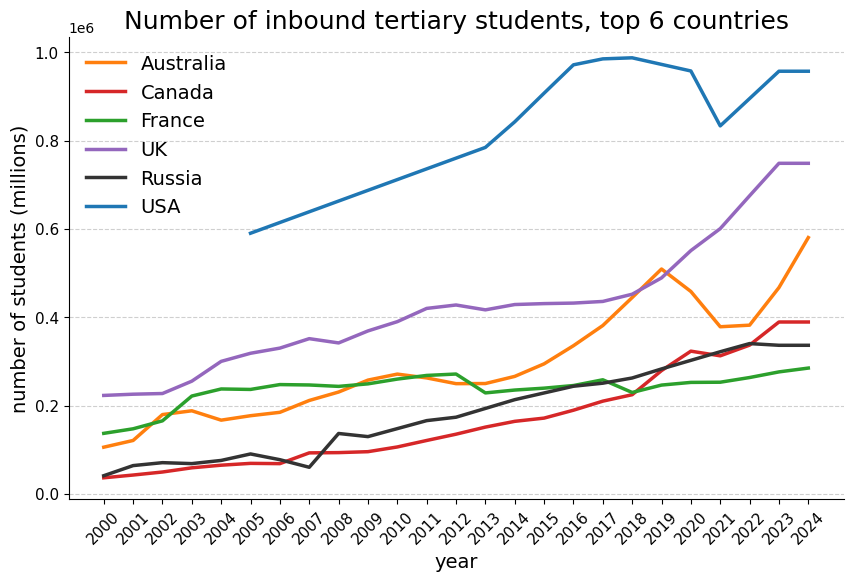

In [30]:
# plot top 6 countries by number of inbound and outbound students
plt.figure(figsize=(10,6))
cond = inbound['country'].isin(top_6_inbound)
country_colors = {
    'USA': '#1f77b4',     # Hex code for a nice blue
    'Australia': '#ff7f0e',  # Orange
    'Canada': '#d62728',   # Red
    'France': '#2ca02c',   # Green
    'UK': '#9467bd', # Purple
    'Russia': '#333333'
}
sns.lineplot(data = inbound[cond], x = 'year', y = 'value', hue = 'country',
             linewidth = 2.5,
             palette=country_colors)
plt.title('Number of inbound tertiary students, top 6 countries', fontsize = 18)
plt.ylabel('number of students (millions)', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(inbound['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

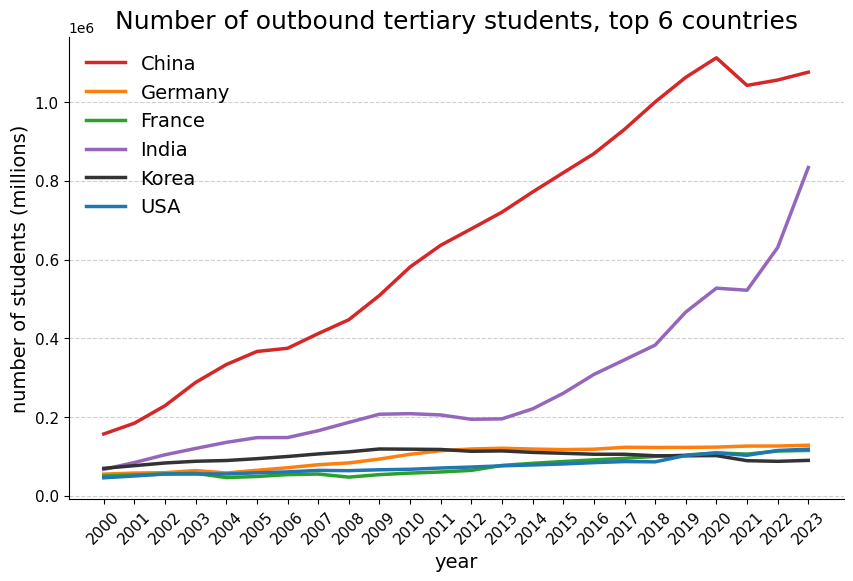

In [32]:
plt.figure(figsize=(10,6))
cond = outbound['country'].isin(top_6_outbound)
country_colors = {
    'USA': '#1f77b4',     # Hex code for a nice blue
    'Germany': '#ff7f0e',  # Orange
    'China': '#d62728',   # Red
    'France': '#2ca02c',   # Green
    'India': '#9467bd', # Purple
    'Korea': '#333333'
}
sns.lineplot(data = outbound[cond], x = 'year', y = 'value', hue = 'country',
             linewidth = 2.5,
             palette=country_colors)
plt.title('Number of outbound tertiary students, top 6 countries', fontsize = 18)
plt.ylabel('number of students (millions)', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(outbound['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

In [ ]:
inbound = inbound.rename(columns = {'value': 'students'})
outbound = outbound.rename(columns = {'value': 'students'})


,geoUnit,year,students,country
24,AFG,2000,2454.0,Afghanistan
25,AFG,2001,2467.0,Afghanistan


In [ ]:
# merge inbound and outbound and calculate student flux
merged = inbound.merge(outbound, on=['country', 'year'], suffixes = ('_inbound', '_outbound')).drop(columns = ['geoUnit_outbound'])
merged['flux'] = merged['students_inbound'].sub(merged['students_outbound'])

,geoUnit_inbound,year,students_inbound,country,students_outbound,flux
3931,ZWE,2019,633.0,Zimbabwe,19703.0,-19070.0
3932,ZWE,2020,633.0,Zimbabwe,19456.0,-18823.0
3933,ZWE,2021,633.0,Zimbabwe,20102.0,-19469.0
3934,ZWE,2022,633.0,Zimbabwe,22271.0,-21638.0
3935,ZWE,2023,633.0,Zimbabwe,24392.0,-23759.0


In [59]:
top_10 = merged.groupby('country')['flux'].sum().sort_values(ascending=False)[0:10]
bottom_10 = merged.groupby('country')['flux'].sum().sort_values(ascending=True)[0:10]

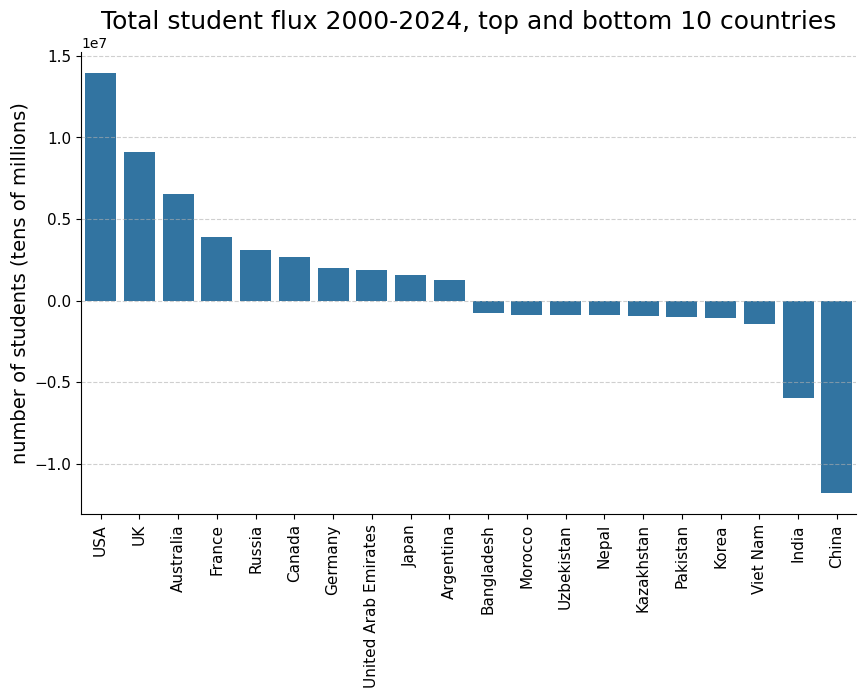

In [99]:
plot_series = pd.concat([top_10, bottom_10.sort_values(ascending=False)], axis=0)
plt.figure(figsize=(10,6))
# plot_series.index
# # plot_series.plot(kind='bar')
sns.barplot(data=plot_series)
plt.title('Total student flux 2000-2024, top and bottom 10 countries', fontsize = 18)
plt.ylabel('number of students (tens of millions)', fontsize = 14)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_series.index.unique(), rotation=90, fontsize = 11)
# plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

In [70]:
bottom_10.sort_values(ascending=False)

country
Bangladesh     -763444.0
Morocco        -878542.5
Uzbekistan     -880355.0
Nepal          -900753.0
Kazakhstan     -920931.0
Pakistan       -988498.0
Korea         -1064865.0
Viet Nam      -1409804.0
India         -5976185.0
China        -11808670.0
Name: flux, dtype: float64